# GloFAS Riverine Discharge Pipeline

This notebook demonstrates the GloFAS v4.0 riverine discharge pipeline: a 51-member ensemble river discharge forecast, sparse-filtered to flood-relevant cells and stored as a compressed Zarr ZipStore.


## Overview

| Step | What happens |
|---|---|
| 1. Download | `ensemble_perturbed_forecasts` (50 members) + `control_forecast` (1) via `cdsapi`, global 60°S-60°N, 7 daily lead times (24-168h) |
| 2. Sparse filter | Keep only cells where ≥1 of 51 members, on ≥1 of 7 days, exceeds the RP2yr threshold — everything else is dropped entirely |
| 3. Build Zarr | Compressed ZipStore, `float32`, shape `(member=51, step=7, n_cells)` — **sparse**, not a dense lat/lon grid |
| 4. Stage (optional) | Upload to Snowflake internal stage and insert a `RIVER_FORECASTS` metadata row |

**Key facts about the data:**
- Values are **not accumulated** (unlike `tp`/`ro`) — each step is discharge in the preceding 24h, read directly
- Member index `i` → ECMWF member `member_numbers[i]` (1-50 = ENS perturbed, 51 = control) — same numbering convention as `TC_TRACKS.ENSEMBLE_MEMBER` and the precip/wind pipelines
- The Zarr's `data` array has **no fixed lat/lon grid index** — use the parallel `cell_lat`/`cell_lon` arrays to locate each stored value; visualizations reconstruct a dense raster from these for plotting
- Requires the official RP threshold files to already be cached (`setup_glofas_thresholds.py`, run once manually) — the sparse filter depends on them

| Output file | Snowflake table | Shape |
|---|---|---|
| `river_YYYYMMDD.zarr.zip` | `RIVER_FORECASTS` | `(51 members, 7 steps, n_cells)` — n_cells varies by date/region activity |

## Setup

In [24]:
import numpy as np
from pathlib import Path

from glofas_downloader import download_glofas_forecast
from visualization import (
    show_glofas_ensemble_mean, show_glofas_period_panels, show_glofas_exceedance,
    find_glofas_hotspot, find_glofas_active_cell, show_glofas_gauge_hydrograph,
)

In [25]:
# ── Date selection ──────────────────────────────────────────────────────────
#
# GloFAS's cache key is date-only (no run-time component) — it publishes once
# per calendar day, driven only by the 00Z IFS ENS cycle, with ~11h publication
# latency. If the requested date isn't published yet, the downloader
# automatically falls back to the previous day (logged clearly when it happens).

SELECTED_DATE = "2026-07-02"   # "YYYY-MM-DD"

# ── Threshold source ─────────────────────────────────────────────────────────
# 'local' avoids needing Snowflake credentials for this demo — requires the RP
# threshold files already cached locally (setup_glofas_thresholds.py --local-only).
# In production this defaults to 'snowflake' even when DATA_PIPELINE_DB=LOCAL,
# since thresholds are static reference files cached independently of storage mode.
THRESHOLD_SOURCE = "local"
THRESHOLD_LOCAL_DIR = "glofas_thresholds"

# ── Visualization settings ───────────────────────────────────────────────────
GLOFAS_STEP_H = 72          # lead hour for ensemble mean / exceedance maps (24-168)
GLOFAS_RP = "2.0"           # return-period tier for the exceedance map (2.0/5.0/.../500.0)

# Output directory
GLOFAS_DIR = Path('glofas_data')
GLOFAS_DIR.mkdir(exist_ok=True)

print(f"Target: {SELECTED_DATE}")

Target: 2026-07-02


## Step 1: Download GloFAS Discharge Forecast

Downloads the ensemble (50 members) and control (1 member) forecasts, applies the sparse RP2yr filter, and builds the Zarr.

In [26]:
d = SELECTED_DATE.replace('-', '')
zarr_path = GLOFAS_DIR / f"river_{d}.zarr.zip"

if zarr_path.exists():
    print(f"Found existing file — skipping download.")
else:
    result = download_glofas_forecast(
        date=SELECTED_DATE,
        output_dir=str(GLOFAS_DIR),
        upload_to_stage=False,
        threshold_source=THRESHOLD_SOURCE,
        threshold_local_dir=THRESHOLD_LOCAL_DIR,
        verbose=True,
    )
    if not result['success']:
        raise RuntimeError(
            f"Download failed for {SELECTED_DATE}. GloFAS is only available for "
            "recent dates, and only once it's been published (~11h after the 00Z "
            "cycle) — try an earlier date if this keeps failing."
        )
    zarr_path = result['zip_path']

print(f"Zarr ZipStore : {zarr_path}")
print(f"File size     : {Path(zarr_path).stat().st_size / 1e6:.0f} MB")

Found existing file — skipping download.
Zarr ZipStore : glofas_data/river_20260702.zarr.zip
File size     : 304 MB


## Inspect the Zarr File

Quick sanity check: sparse shape, member numbering, and the fraction of the global grid actually kept by the RP2yr filter.

In [27]:
import zarr

store = zarr.storage.ZipStore(str(zarr_path), mode='r')
root  = zarr.open_group(store=store, mode='r')
z     = root['data']
attrs = dict(root.attrs)

print("=== Zarr metadata ===")
print(f"  Shape (sparse) : {z.shape}  (members, steps, n_cells)")
print(f"  Dtype          : {z.dtype}")
print(f"  Forecast date  : {attrs['forecast_date']}")
print(f"  Lead hours     : {attrs['leadtime_hours']}")
print(f"  member_numbers : {attrs['member_numbers']}")
print(f"  Filter         : {attrs['filter_threshold']}")
n_kept, n_total = attrs['n_cells_kept'], attrs['n_cells_total']
print(f"  Cells kept     : {n_kept:,} of {n_total:,}  ({100*n_kept/n_total:.2f}%)")
print()
print("=== Data checks ===")
arr = np.asarray(z)
print(f"  Max discharge (any member/day/cell)     : {arr.max():.0f} m3/s")
print(f"  Min discharge (any member/day/cell)     : {arr.min():.2f} m3/s")
print(f"  Would float16 have overflowed (>65504)? : {arr.max() > 65504}")
store.close()

=== Zarr metadata ===
  Shape (sparse) : (51, 7, 472930)  (members, steps, n_cells)
  Dtype          : float32
  Forecast date  : 20260702
  Lead hours     : [24, 48, 72, 96, 120, 144, 168]
  member_numbers : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  Filter         : RP2.0yr
  Cells kept     : 472,930 of 17,280,000  (2.74%)

=== Data checks ===
  Max discharge (any member/day/cell)     : 117180 m3/s
  Min discharge (any member/day/cell)     : 0.00 m3/s
  Would float16 have overflowed (>65504)? : True


## Visualizations

Five complementary views of the ensemble discharge forecast. GloFAS's Zarr is sparse (only kept cells stored, with parallel `cell_lat`/`cell_lon` arrays).

- **Ensemble mean** — global map of mean discharge across all 51 members at `GLOFAS_STEP_H`
- **Period panels** — how the forecast evolves across the 7-day horizon (ensemble max per day)
- **RP exceedance (global)** — fraction of members exceeding the official `GLOFAS_RP`-year return period threshold
- **RP exceedance (zoomed)** — same map, automatically zoomed into the single strongest exceedance cluster found in this forecast
- **Gauge hydrograph** — all 51 member traces at a single cell over the 7-day horizon, with official RP threshold lines (Warning/Danger/Extreme-style)

GLOFAS — ENSEMBLE MEAN DISCHARGE
  Lead: +72h  |  Cells: 472,930 of 17,280,000 total  |  Max mean discharge: 68297 m3/s


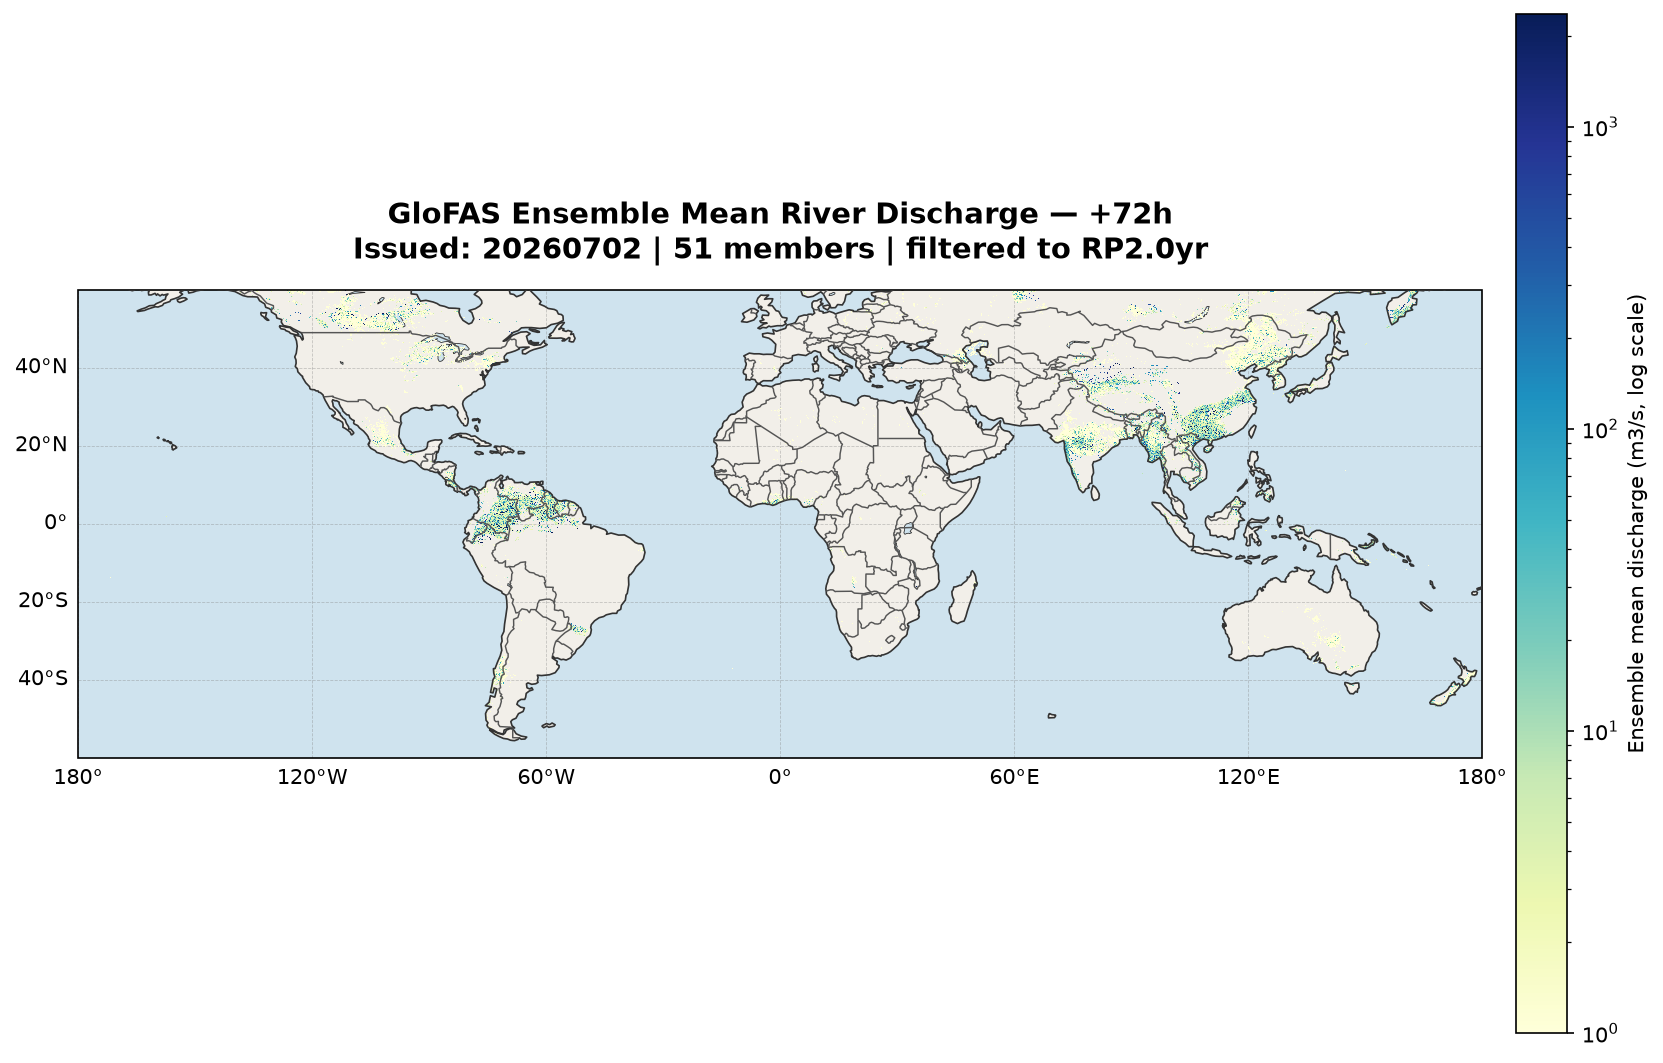

In [28]:
# Ensemble mean discharge at GLOFAS_STEP_H, global
show_glofas_ensemble_mean(zarr_path, step_h=GLOFAS_STEP_H)

GLOFAS — MULTI-DAY ENSEMBLE MAX PANELS


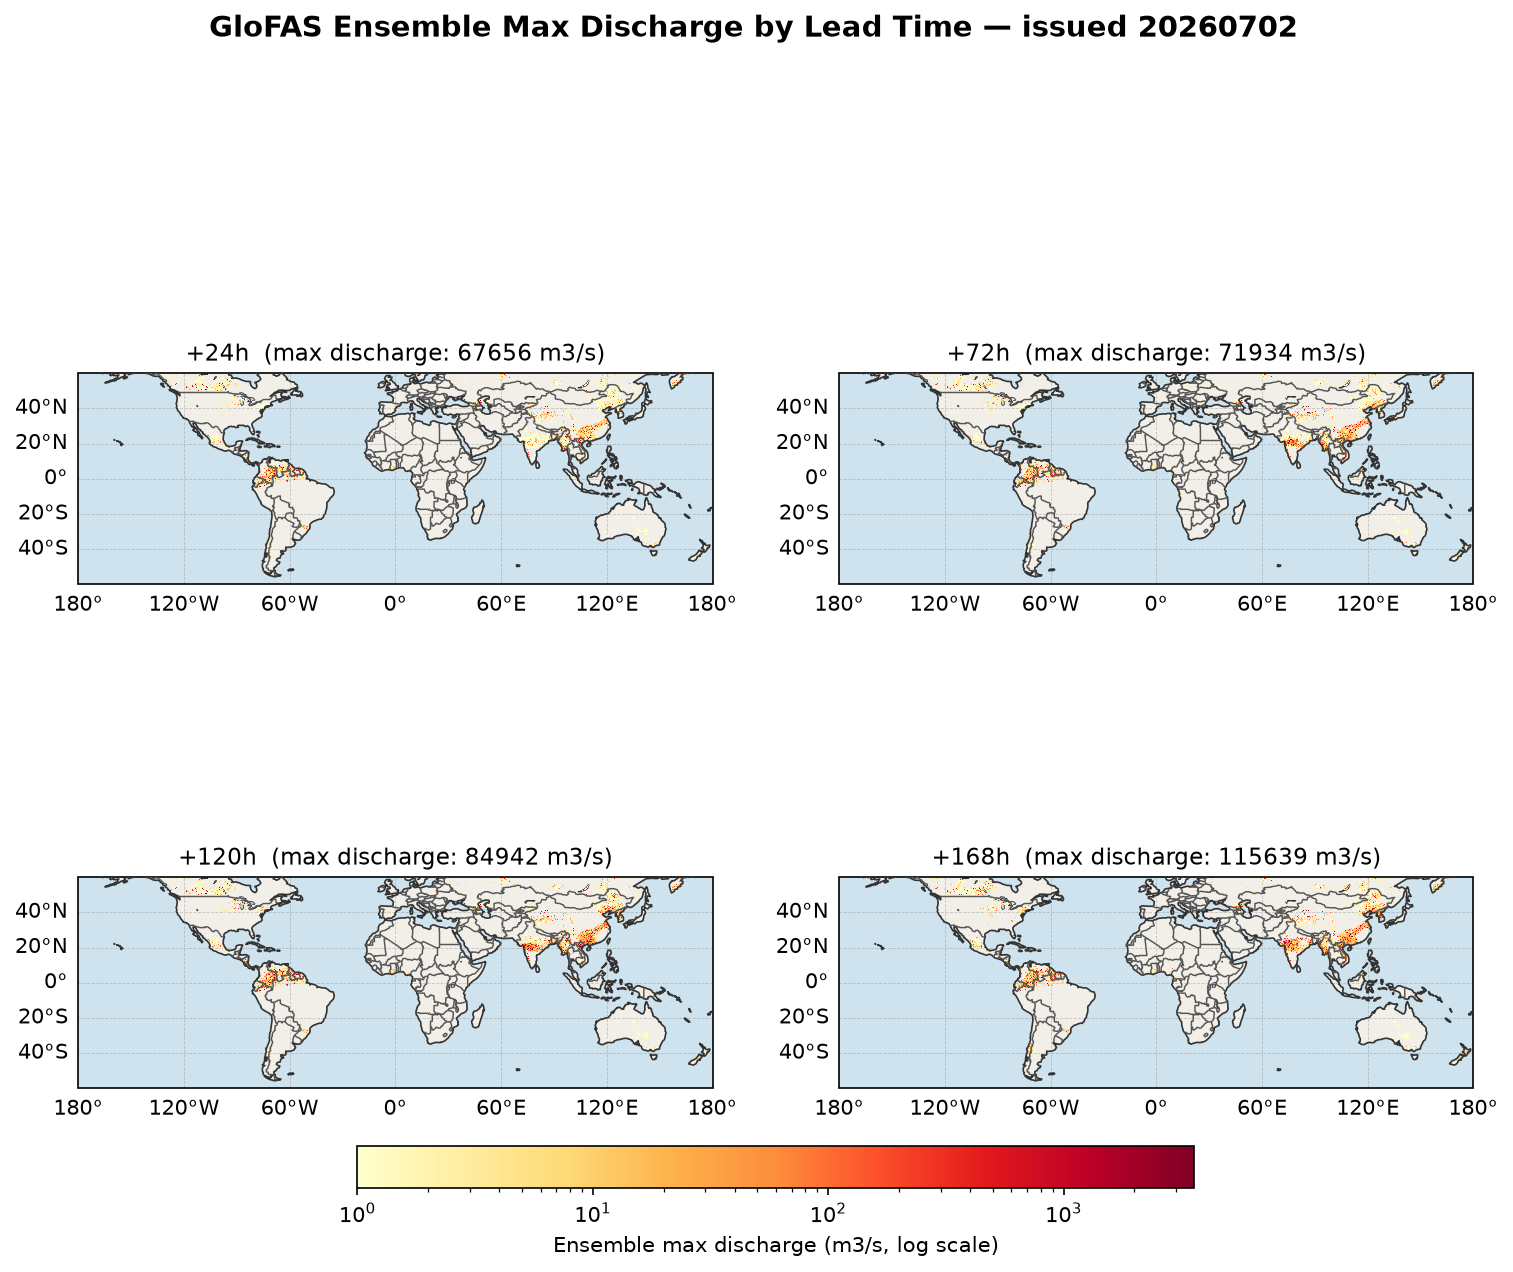

In [29]:
# Multi-day ensemble max panels
show_glofas_period_panels(zarr_path)

GLOFAS — RP2.0yr EXCEEDANCE PROBABILITY (+72h)
  Cells with any threshold data : 472,930 of 472,930
  Cells with >50% members exceeding RP2.0yr : 63,914


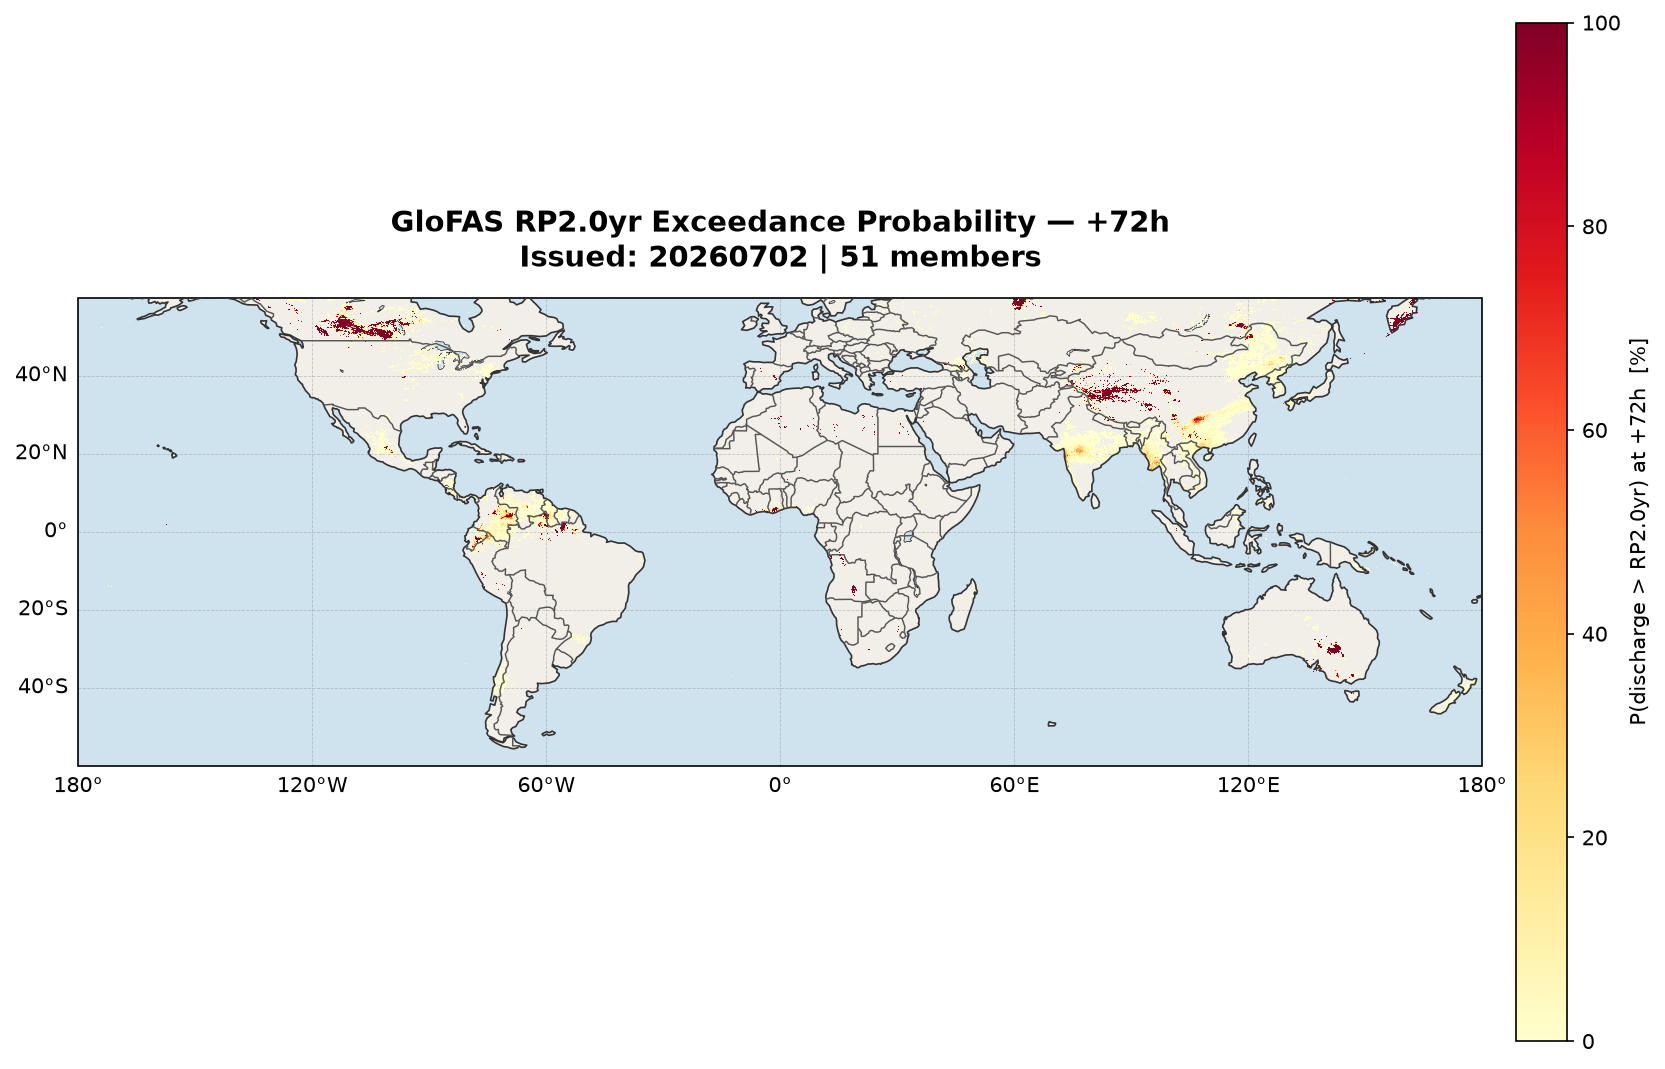

In [30]:
# Probability that discharge exceeds the official RP threshold by GLOFAS_STEP_H
# Try a higher RP (e.g. '20.0') to see a much more selective, higher-confidence map
show_glofas_exceedance(zarr_path, threshold_local_dir=THRESHOLD_LOCAL_DIR, rp=GLOFAS_RP, step_h=GLOFAS_STEP_H)

  Hotspot: 1385 cells near lat=53.9, lon=-112.0  -> bounds=(-125.0, -99.0, 41.0, 67.0)
GLOFAS — RP2.0yr EXCEEDANCE PROBABILITY (+72h)  [ZOOMED]
  Cells with any threshold data : 472,930 of 472,930
  Cells with >50% members exceeding RP2.0yr : 63,914


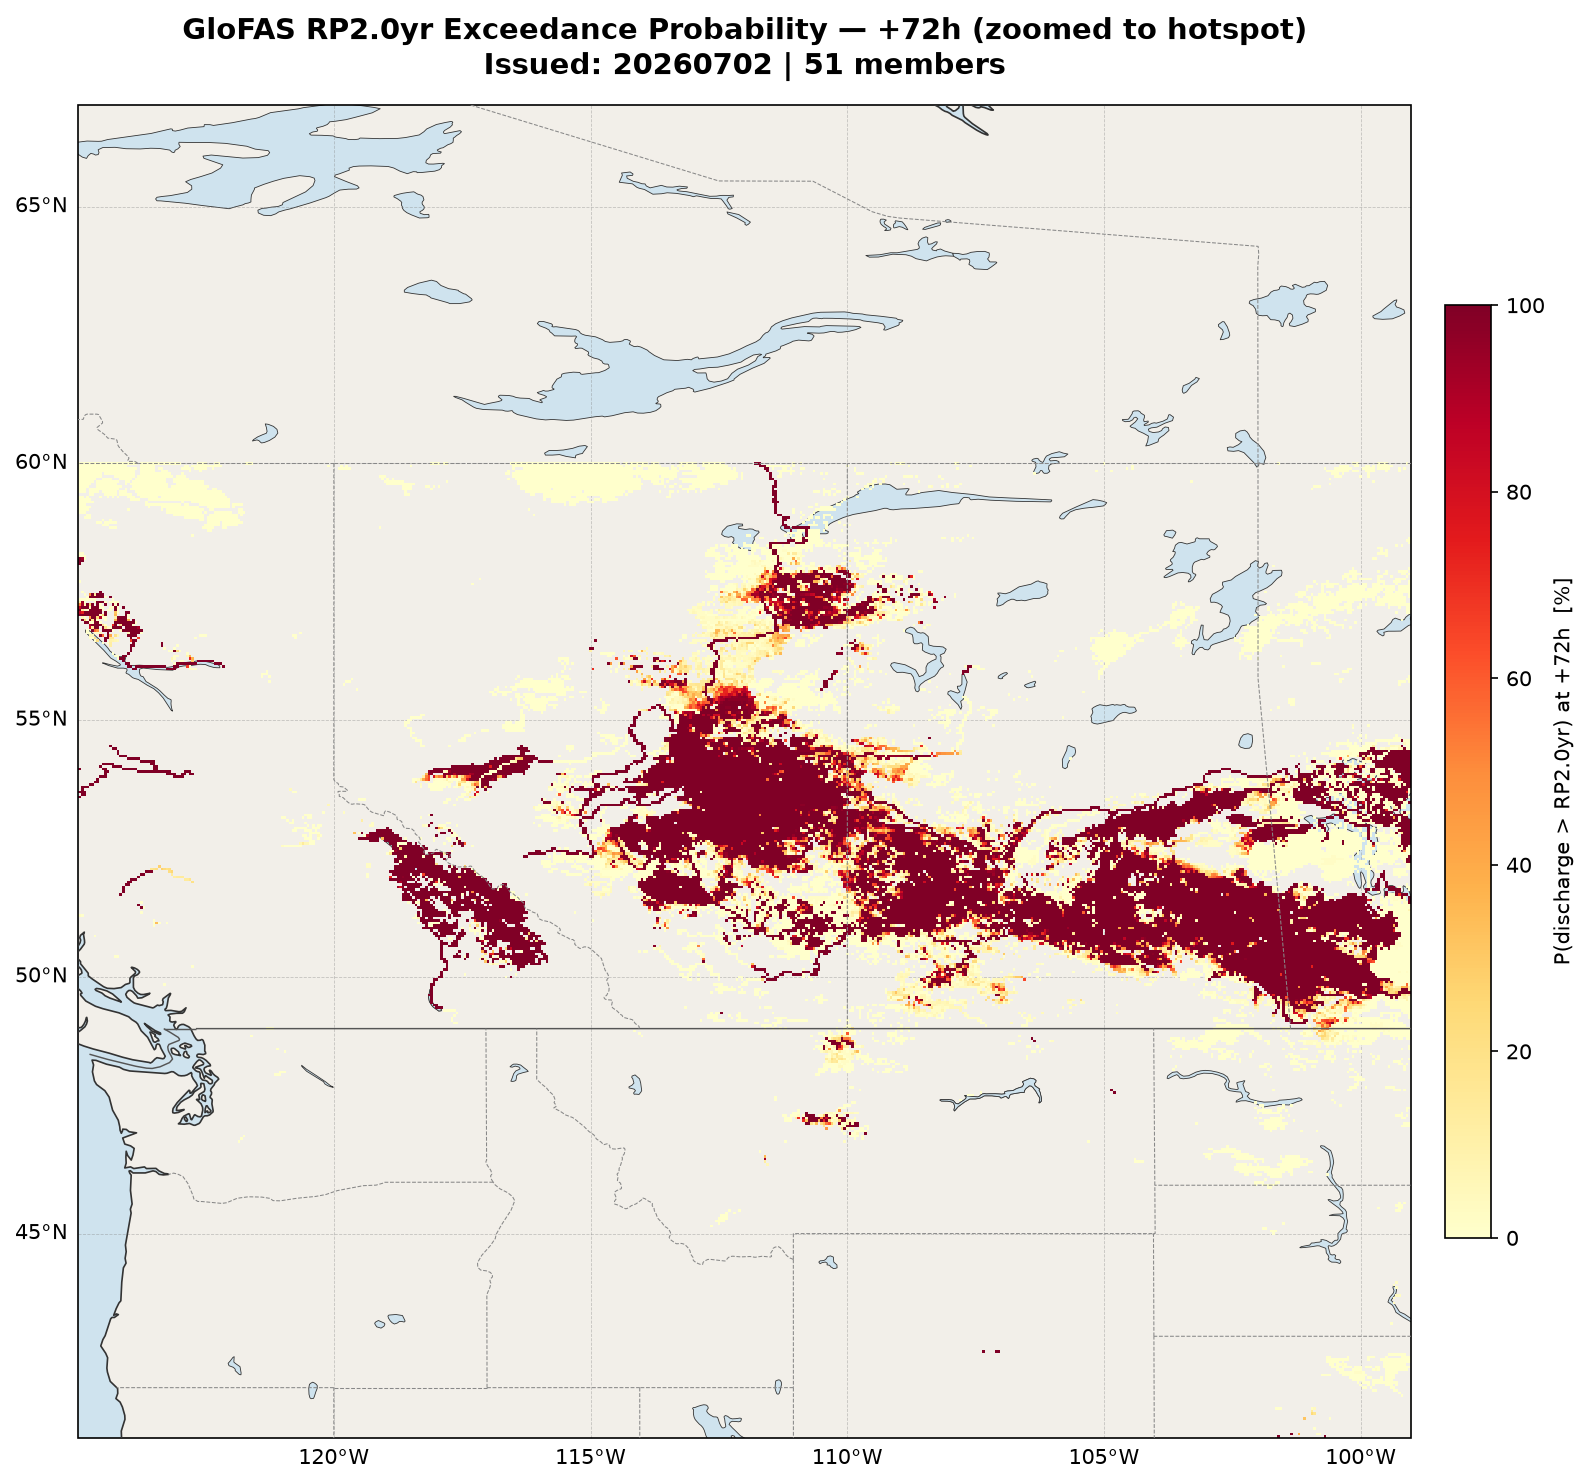

In [31]:
# Zoom into the single strongest exceedance cluster in this forecast, automatically
# located, not a hardcoded region, so this adapts to whatever the forecast actually shows.
hotspot_bounds = find_glofas_hotspot(zarr_path, threshold_local_dir=THRESHOLD_LOCAL_DIR,
                                     rp=GLOFAS_RP, step_h=GLOFAS_STEP_H)
if hotspot_bounds:
    show_glofas_exceedance(zarr_path, threshold_local_dir=THRESHOLD_LOCAL_DIR,
                          rp=GLOFAS_RP, step_h=GLOFAS_STEP_H, bounds=hotspot_bounds)

  Most active cell: lat=22.18, lon=113.43  (max discharge rises 35605 -> 115639 m3/s over the horizon)
GLOFAS — GAUGE HYDROGRAPH
  Cell: lat=22.18, lon=113.43
  Peak across all members/days: 115639 m3/s
  Thresholds found: RP2.0yr=48171, RP5.0yr=59033, RP20.0yr=73123


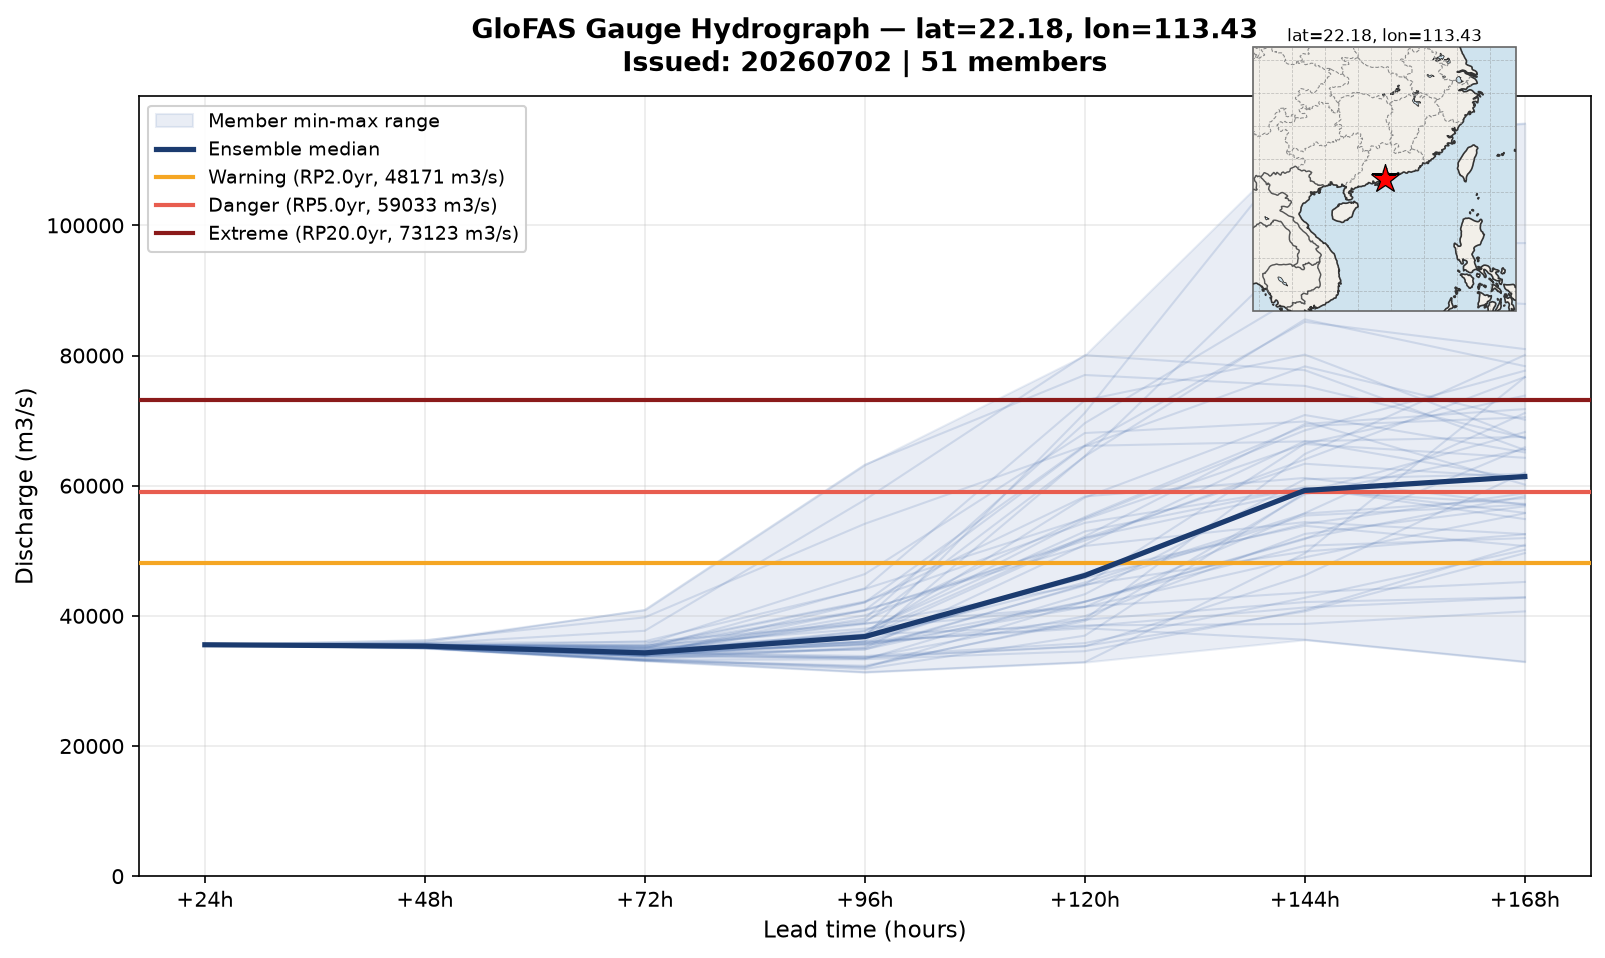

In [32]:
# Single-gauge hydrograph: all 51 member traces + RP threshold lines, at the
# cell with the most dramatic developing signal in this forecast (auto-selected,
# not hardcoded, pass cell_lat/cell_lon explicitly to pick own location instead)
active_lat, active_lon = find_glofas_active_cell(zarr_path)
show_glofas_gauge_hydrograph(zarr_path, cell_lat=active_lat, cell_lon=active_lon,
                             threshold_local_dir=THRESHOLD_LOCAL_DIR)